In [1]:
from utils.binaries import *
from utils.plotting import *

import healpy as hp
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, Column

import os

21:49:05 (  +35.3s) [INFO   ] -- import logging
21:49:05 (   +74ms) [INFO   ] -- import numpy as np
21:49:05 (    +7ms) [INFO   ] -- import uncertainties
21:49:05 (  +214ms) [INFO   ] -- import pandas as pd
21:49:05 (    +1ms) [WARNING] -- pandas support to be dropped at some point!
21:49:05 (    +1ms) [INFO   ] -- import binaries.tools as tools
21:49:05 (    +1ms) [INFO   ] -- set MONI_PATH = PosixPath('/home/filip/Data/monit_and_sd')
21:49:05 (    +1ms) [INFO   ] -- set HIST_PATH = PosixPath('/home/filip/Data/monit_and_sd')
21:49:05 (    +1ms) [INFO   ] -- set PLOT_PATH = PosixPath('/home/filip/Data/plots')
21:49:05 (    +0ms) [INFO   ] -- set DATA_PATH = PosixPath('/home/filip/Data')
21:49:05 (    +1ms) [INFO   ] -- set SCAN_PATH = PosixPath('/home/filip/Public/xy-calibration')
21:49:05 (    +0ms) [INFO   ] -- set OFLN_PATH = PosixPath('/home/filip/Public/offline/install')
21:49:06 (  +335ms) [INFO   ] -- import matplotlib.pyplot as plt
21:49:06 (  +325ms) [INFO   ] -- import seabor

In [30]:
def MapToHealpyCoord(l, b):
	return l, np.pi/2 - b

# def DatasetLoad(fdir = "./Data",filename = "AugerApJS2022_Yr_JD_UTC_Th_Ph_RA_Dec_E_Expo"):
def DatasetLoad(fdir = "./Data",filename = "Herald080noBP5n6t5a4_010104-310816.dat"):

	fname = os.path.join(fdir,filename)
	if os.path.isfile(fname):
		table = Table.read(fname, format='ascii.basic', delimiter=" ", guess=False)

		#equatorial and Galactic coordinates
		sc_equatorial = SkyCoord(table["RA"], table["Dec"], unit=u.deg)
		table.add_column(sc_equatorial, name="sc_eq")
		table.add_column(sc_equatorial.galactic, name="sc_gal")
		table.add_column(sc_equatorial.supergalactic, name="sc_sgal")		
		#Spherical coordinates for healpy
		phi, theta = MapToHealpyCoord(table["sc_gal"].l.to(u.rad).value, table["sc_gal"].b.to(u.rad).value)
		table.add_column(Column(phi), name="phi")
		table.add_column(Column(theta), name="theta")		
		
		export = ["UTC","sc_eq","sc_gal","sc_sgal","phi", "theta", "E"]
		
		return table[export]
	
def DirectionalExposureLoad(expo_tot_km2yrsr, fdir = "./Data",filename = "exposure.fits"):

	fname = os.path.join(fdir,filename)
	if os.path.isfile(fname):
		hpx, header = hp.read_map(fname, h=True)
		return expo_tot_km2yrsr*hpx/np.sum(hpx)
	

def PlotLiMa(expo_map, table_data, Emin_EeV = 41, radius_deg = 27, save_filename=None):


	def LiMaMap(nside, Non, Noff, alpha):

		Non_log_term = (1. + alpha)*Non / (alpha*(Non + Noff))
		Noff_log_term = (1. + alpha)*Noff / (Non + Noff)
		
		sig2_ov_2 = np.zeros_like(Non)
		ind = np.where((Non > 0) & (alpha > 0)) # ensures non negative log terms induced by smoothing
		sig2_ov_2[ind] += Non[ind]*np.log(Non_log_term[ind])
		ind = np.where(Noff > 0) # ensures non negative log terms induced by smoothing
		sig2_ov_2[ind] += Noff[ind]*np.log(Noff_log_term[ind])

		return np.sign(Non-alpha*Noff)*np.sqrt(np.abs(2*sig2_ov_2))
		
	# Load count map above Emin
	nside = hp.get_nside(expo_map)
	count_map = LoadCountMap(table_data, nside, Eth = Emin_EeV)

	# Smooth exposure and count maps
	smoothed_expo_map = LoadSmoothedMap(expo_map, radius_deg)
	smoothed_count_map = LoadSmoothedMap(count_map, radius_deg)	
	
	# Normalize to the total number of events in the smoothing region
	solid_angle_per_pix = 4.*np.pi / hp.nside2npix(nside)
	solid_angle = 2.*np.pi * (1. - np.cos(np.radians(radius_deg)))
	npix_per_region = solid_angle/solid_angle_per_pix

	# alpha, Non, & Noff
	alpha = smoothed_expo_map / (np.sum(expo_map)/npix_per_region - smoothed_expo_map)
	Non = smoothed_count_map*npix_per_region
	Noff = np.sum(count_map) - Non

	# Significance map
	sig_map = LiMaMap(nside, Non, Noff, alpha) # Compute the significance map
	isig_max = np.argmax(sig_map)
	sel = expo_map>np.max(expo_map)/100#empty pixels where the exposure is zero
	sig_map[np.invert(sel)] = np.nan #uniform above maximum dec
	sig_min = np.min(sig_map[sel])
	sig_max = np.max(sig_map[sel])	
	sig_abs = max(np.abs(sig_max),np.abs(sig_min))

	# Plot skymap
	title = r"$\sigma(E_{\rm Auger} \geq"+ f"{Emin_EeV}"+ r"\:{\rm EeV})$ - "+ f"$\Psi = {radius_deg}\\degree$"
	color_bar_title = r"Li & Ma significance"
	PlotHPmap(sig_map, title, color_bar_title, vmin=-sig_abs, vmax=sig_abs)	

def LoadCountMap(dataset, nside, Eth):
	"""
	Loads the count map of the auger phase 1 high-energy data set. 
	"""	
	#Select events >= Eth
	sel = dataset["E"]>=Eth
	
	# Pixel index for each events of coordinates (theta, phi)
	index = hp.ang2pix(nside, np.array(dataset["theta"][sel]), np.array(dataset["phi"][sel]))

	# Count map of parameter nside
	npix = hp.nside2npix(nside)# npix corresponds to the number of pixel associated to a NSIDE healpy map
	count_map = np.histogram(index, bins=np.arange(npix + 1))[0]
	
	return count_map

def LoadSmoothedMap(hp_map, radius_deg, top_hat = True):
	"""
	Return smoothed map with a top-hat beam of radius radius_deg
	"""	
	nside = hp.get_nside(expo_map)
	radius_rad = np.radians(radius_deg)	

	def top_hat_beam(radius_rad, nside):
		b = np.linspace(0.0, np.pi, 10000)
		bw = np.where(abs(b) <= radius_rad, 1, 0)
		return hp.sphtfunc.beam2bl(bw, b, lmax=nside*3) #beam in the spherical harmonics space

	def fisher_beam(radius_rad, nside):
		b = np.linspace(0.0, np.pi, 10000)
		kappa = 1./(2*(1.-np.cos(radius_rad)))
		bw = np.exp(kappa*np.cos(b))
		return hp.sphtfunc.beam2bl(bw, b, lmax=nside*3)#beam in the spherical harmonics space
	
	if(top_hat):
		solid_angle = 2.*np.pi*(1. - np.cos(radius_rad))
		return hp.smoothing(hp_map, beam_window=top_hat_beam(radius_rad, nside)) / solid_angle
	else:
		return hp.smoothing(hp_map, beam_window=fisher_beam(radius_rad, nside)) #note: this one is not normalized

In [31]:
table_data = DatasetLoad()

expo_map = DirectionalExposureLoad(expo_tot_km2yrsr = 122E3)

Emin_EeV = 8
radius_deg = 45

In [42]:
def PlotHPmap(hp_map, title, color_bar_title, save_filename=None, projection="hammer", cmap='seismic', vmin=None, vmax=None, ax=None, src_list=None):

	# Transform healpix map into matplotlib map (grid_map)
	xsize = 2000 # grid size for matplotlib
	ysize = int(xsize/2.)
	theta = np.linspace(np.pi, 0, ysize)
	phi = np.linspace(-np.pi, np.pi, xsize)
	PHI, THETA = np.meshgrid(phi, theta)
	nside = hp.get_nside(hp_map)
	grid_pix = hp.ang2pix(nside, THETA, PHI)
	grid_map = hp_map[grid_pix]

	# # Define the figure
	# width = 12# width of the figure
	# fig = plt.figure(figsize=(width,width/1.5))
	# plt.subplots_adjust(left=0.06, right=0.94, top=0.83, bottom=0.02)
	# fig.suptitle(title, size=30, y = 0.94)

	fig = plt.figure()

	if ax is None:
		ax = fig.add_subplot(111, projection=projection)
		ax.set_aspect("equal")
	# labelsize = 5
	# ax.tick_params(axis='x', labelsize=labelsize)
	# ax.tick_params(axis='y', labelsize=labelsize)
			
	# # Set the size of the other fonts
	# fontsize = 22
	# font = {'size': fontsize}
	# matplotlib.rc('font', **font)
	# matplotlib.rcParams['figure.max_open_warning']=0
	
	# minimum and maximum values along the z-scale (colorbar)
	if vmax is None:
		vmax = np.max(hp_map)
	if vmin is None:
		vmin = np.min(hp_map)
	
	# Plot the map, reverse the longitude axis "[::-1]" (astronomical convention)
	longitude = np.radians(np.linspace(-180, 180, xsize))
	latitude = np.radians(np.linspace(-90, 90, ysize))
	image = ax.pcolormesh(longitude[::-1], latitude, grid_map, rasterized=True, 
						  cmap=plt.get_cmap(cmap), shading='auto', vmin=vmin, vmax=vmax)
	cb = fig.colorbar(image, orientation='vertical', pad=0.05)
	cb.set_label(color_bar_title)

	cb.set_ticklabels([f"${n:+}$" for n in cb.get_ticks()])

	#Supergalactic plane
	l = np.radians(np.linspace(-180, 180, xsize))
	l = (l + np.pi) % 2*np.pi - np.pi
	b = np.zeros_like(l)	
	c = SkyCoord(sgl=l, sgb=b, frame='supergalactic', unit="rad")
	l_sgp, b_sgp = -c.galactic.l.degree, c.galactic.b.degree
	l_sgp = (l_sgp + 180.) % 360. - 180.
	#breaks the array if angular distance is large
	i_br = np.where(np.abs(l_sgp[:-1]-l_sgp[1:])>30)[0]
	ax.plot(np.radians(l_sgp[i_br[0]+1:i_br[1]]),
		 np.radians(b_sgp[i_br[0]+1:i_br[1]]),
		 linewidth=0.7, ls='--', marker='none')	
	
	# x_ticklabels = np.array([fr"${d}\,\degree$" for d in range(0, 330, 30)])
	# x_ticklabels = np.roll(x_ticklabels, 5)
	# x_ticklabels = np.array([fr"${d}\,\degree$" for d in range(-90, 180, 90)])
	# x_ticklabels[1] = "GC"

	# # Plot the labels considering if it is galactic or equatorial coordinates
	# ax.set_xticks(range(-90, 180, 90), x_ticklabels, fontsize=8)
	# ax.tick_params(axis='x', which='major', pad=-105)
	ax.set_xticks([0], [""], fontsize=8)
	ax.text(0, 0, "GC", ha='center', va='center', fontsize=8)

	ax.set_xlabel('l')
	ax.set_ylabel('b')

	y_ticklabels = np.array([fr"${d}\,\degree$" for d in range(-75, 76, 30)])
	ax.set_yticks(ax.get_yticks()[::2], y_ticklabels, fontsize=8)

		
	ax.grid(True, alpha=0.25)
	
	if(src_list!=None):
		for src in src_list:
			name, l, b = src[0], src[1], src[2]
			l = -l
			l = (l + 180.) % 360. - 180.
			plt.annotate(name, (np.radians(l), np.radians(b)), color = "gray", fontsize='small')
			plt.scatter(np.radians(l), np.radians(b), s=20, facecolors='none', edgecolors='gray')

	# dipole
	x_dipole, y_dipole = 113/180 * np.pi, -13
	ax.scatter(x_dipole, y_dipole, marker='x', s=15, lw=0.4)


22:09:49 ( +378.9s) [DEBUG  ] -- font size set to 9.5
22:09:49 (    +3ms) [DEBUG  ] -- label size set to 13.0
22:09:49 (    +0ms) [DEBUG  ] -- figure size set to [3.3, 2.5]
22:09:49 (    +1ms) [DEBUG  ] -- markersize set to 2.0
22:09:49 (    +1ms) [DEBUG  ] -- usetex set to False
/tmp/ipykernel_13917/1306563098.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  cb.set_ticklabels([f"${n:+}$" for n in cb.get_ticks()])


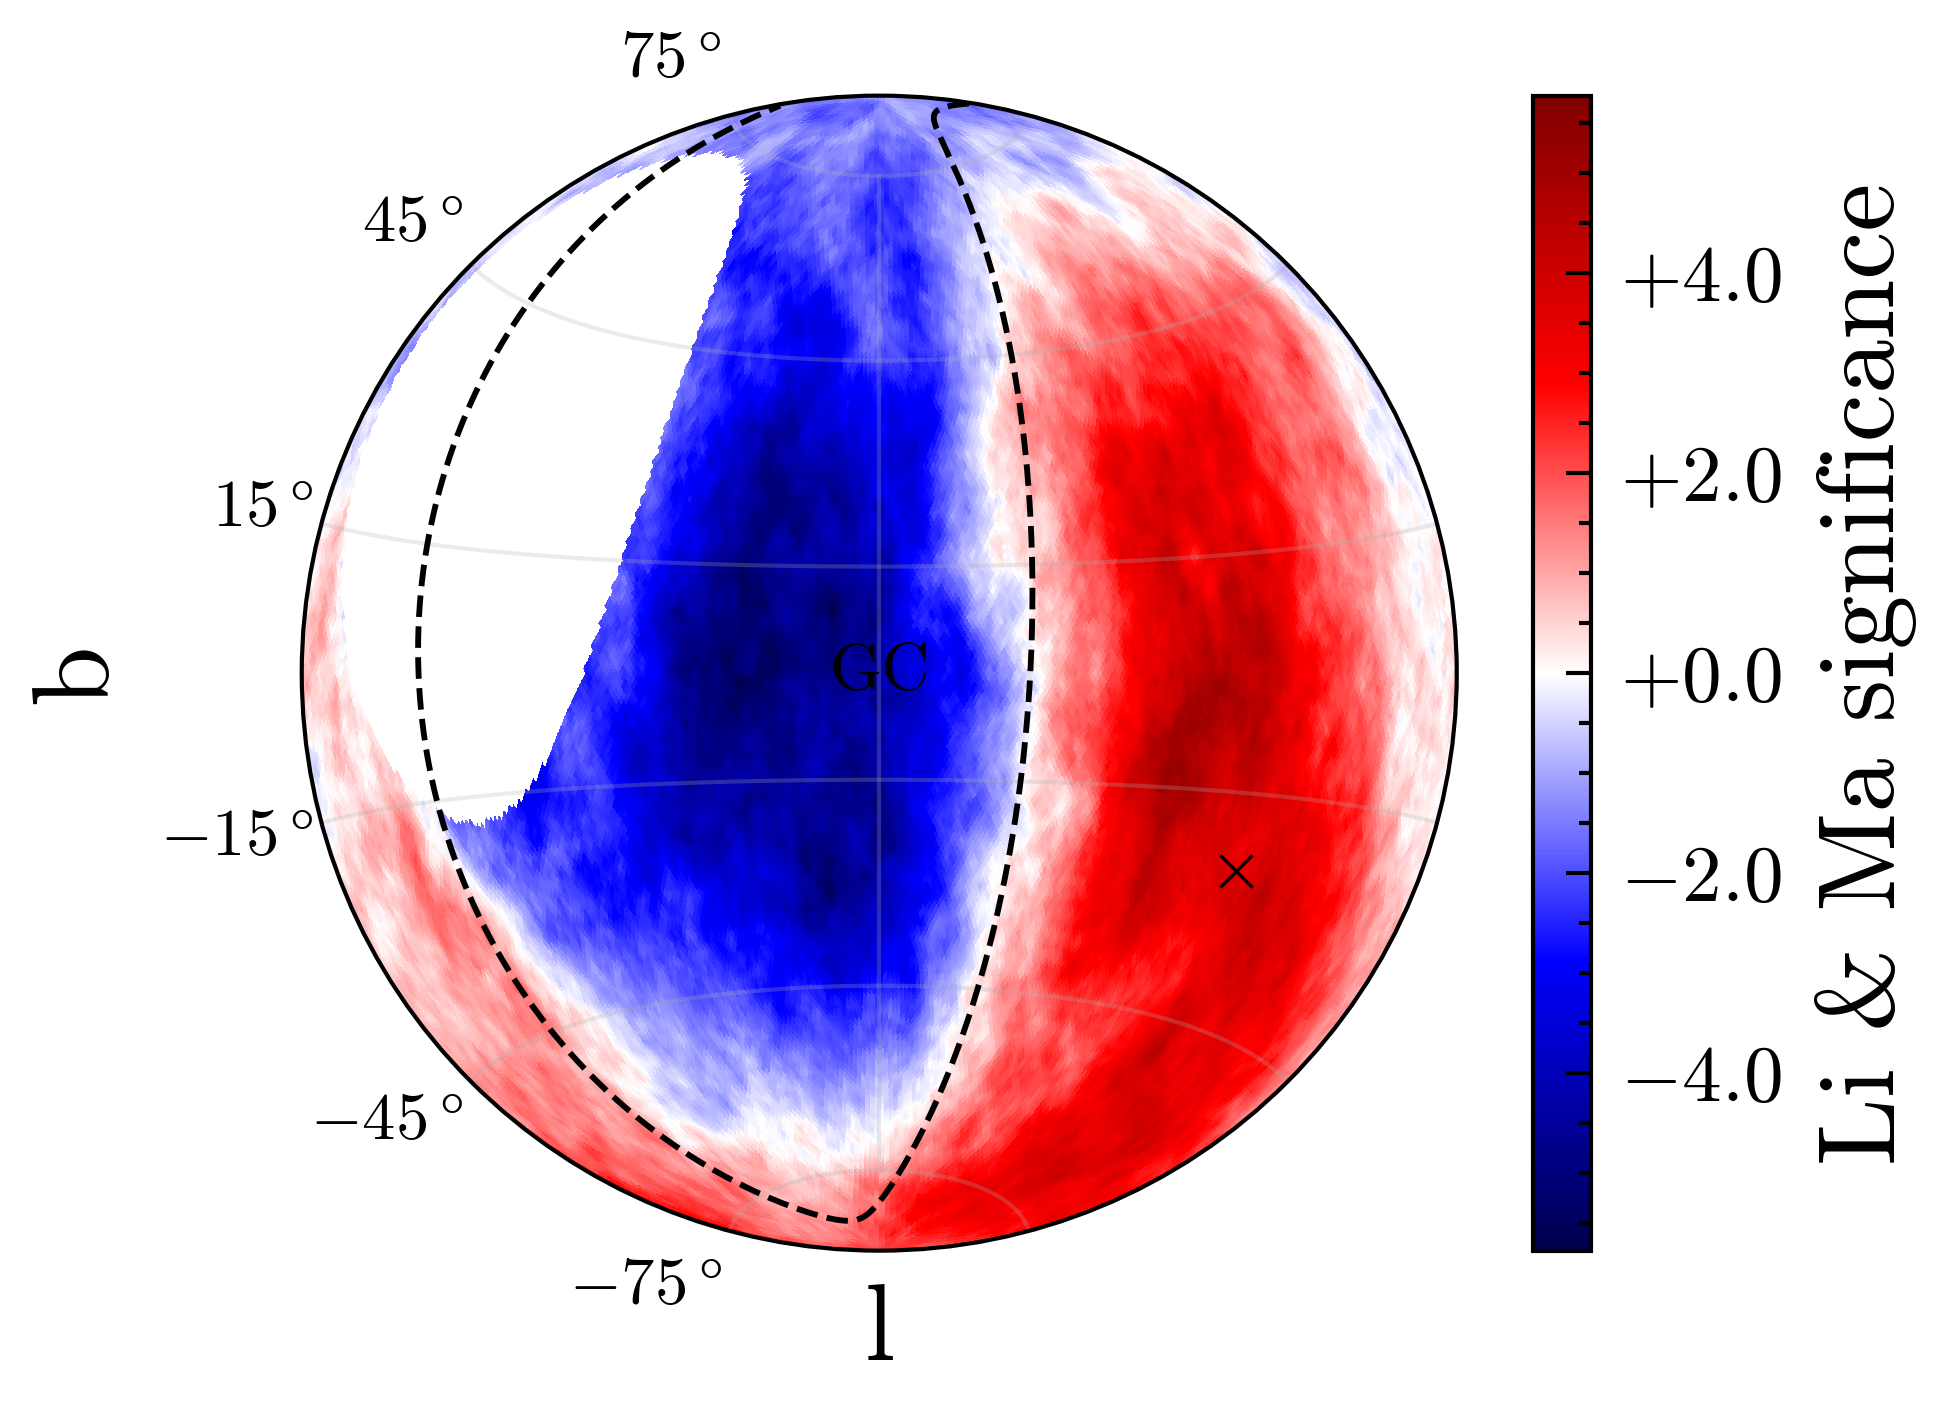

In [43]:
set_plt_style("double")

PlotLiMa(expo_map, 
         table_data, 
         Emin_EeV = Emin_EeV, 
         radius_deg = radius_deg)